# <font color='dark'>**Detecção de texto em placas de carro**</h1>

# <font color='dark'>**Aula 1**</h1>

### Instalação do tesseract

Necessário instalar o tesseract na máquina. Como o Colab utiliza um computador com sistema operacional Linux, é preciso utilizar o comando `!sudo apt install tesseract-ocr`.

Informação disponível na [documentação do tesseract](https://tesseract-ocr.github.io/tessdoc/Installation.html)

Na mesma documentação é possível ver as linguagens disponíveis no [github](https://github.com/tesseract-ocr/tessdata). Para utilizar a língua portuguesa, precisamos usar o arquivo `por.tessdata`

In [ ]:
!sudo apt install tesseract-ocr

Reading package lists... Done
Building dependency tree       
Reading state information... Done
tesseract-ocr is already the newest version (4.00~git2288-10f4998a-2).
The following package was automatically installed and is no longer required:
  libnvidia-common-460
Use 'sudo apt autoremove' to remove it.
0 upgraded, 0 newly installed, 0 to remove and 19 not upgraded.


Para usar o tesseract com a linguagem python, devemos instalar o pacote `pytesseract`, disponível no [PyPI](https://pypi.org/project/pytesseract/).

In [ ]:
!pip install pytesseract

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


Podemos baixar diretamente o arquivo `por.tessdata` do [github](https://github.com/tesseract-ocr/tessdata) ou baixar diretamente para o Google Colab com o comando `wget`.

In [ ]:
!mkdir tessdata

mkdir: cannot create directory ‘tessdata’: File exists


In [ ]:
!wget -O ./tessdata/por.traineddata https://github.com/tesseract-ocr/tessdata/blob/main/por.traineddata?raw=true

--2022-08-08 17:32:03--  https://github.com/tesseract-ocr/tessdata/blob/main/por.traineddata?raw=true
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/tesseract-ocr/tessdata/raw/main/por.traineddata [following]
--2022-08-08 17:32:03--  https://github.com/tesseract-ocr/tessdata/raw/main/por.traineddata
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/tesseract-ocr/tessdata/main/por.traineddata [following]
--2022-08-08 17:32:04--  https://raw.githubusercontent.com/tesseract-ocr/tessdata/main/por.traineddata
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awa

### Importação das bibliotecas

In [ ]:
import cv2
import pytesseract

In [ ]:
cv2.__version__

'4.6.0'

In [ ]:
pytesseract.__version__

'0.3.9'

### Leitura da imagem

In [ ]:
imagem = cv2.imread('/content/trecho_livro.png')

In [ ]:
from google.colab.patches import cv2_imshow

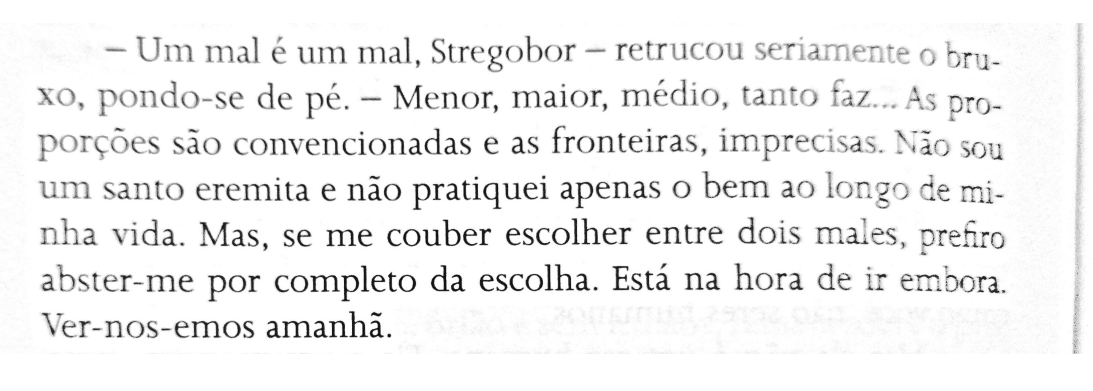

In [ ]:
cv2_imshow(imagem)

In [ ]:
texto = pytesseract.image_to_string(imagem)
print(texto)

— Um mal é um mal, Stregobor — retrucou seriamente 0 bry.
xo, pondo-se de pé. — Menor, maior, médio, tanto faz... A
porgdes sao convencionadas e as fronteiras, imprecisas.
um santo eremita e nao pratiquei apenas 0 bem ao longo de mi-
nha vida. Mas, se me couber escolher entre dois males, prefiro

abster-me por completo da escolha. Esta na hora de ir embora.
Ver-nos-emos amanha.

 

S pro-

40 SOU

 

 



In [ ]:
!tesseract --help-psm

Page segmentation modes:
  0    Orientation and script detection (OSD) only.
  1    Automatic page segmentation with OSD.
  2    Automatic page segmentation, but no OSD, or OCR.
  3    Fully automatic page segmentation, but no OSD. (Default)
  4    Assume a single column of text of variable sizes.
  5    Assume a single uniform block of vertically aligned text.
  6    Assume a single uniform block of text.
  7    Treat the image as a single text line.
  8    Treat the image as a single word.
  9    Treat the image as a single word in a circle.
 10    Treat the image as a single character.
 11    Sparse text. Find as much text as possible in no particular order.
 12    Sparse text with OSD.
 13    Raw line. Treat the image as a single text line,
       bypassing hacks that are Tesseract-specific.


In [ ]:
config_tesseract = '--tessdata-dir tessdata --psm 6'
texto = pytesseract.image_to_string(imagem, lang = 'por', config = config_tesseract)
print(texto)

— Um mal é um mal, Stregobor — retrucou seriamente o bry-
xo, pondo-se de pé. — Menor, maior, médio, tanto faz... As pro-
porções são convencionadas e as fronteiras, imprecisas. Não sou
um santo eremita e não pratiquei apenas o bem ao longo de mi-
nha vida. Mas, se me couber escolher entre dois males, prefiro
abster-me por completo da escolha. Está na hora de ir embora. ;
Ver-nos-emos amanhã. |



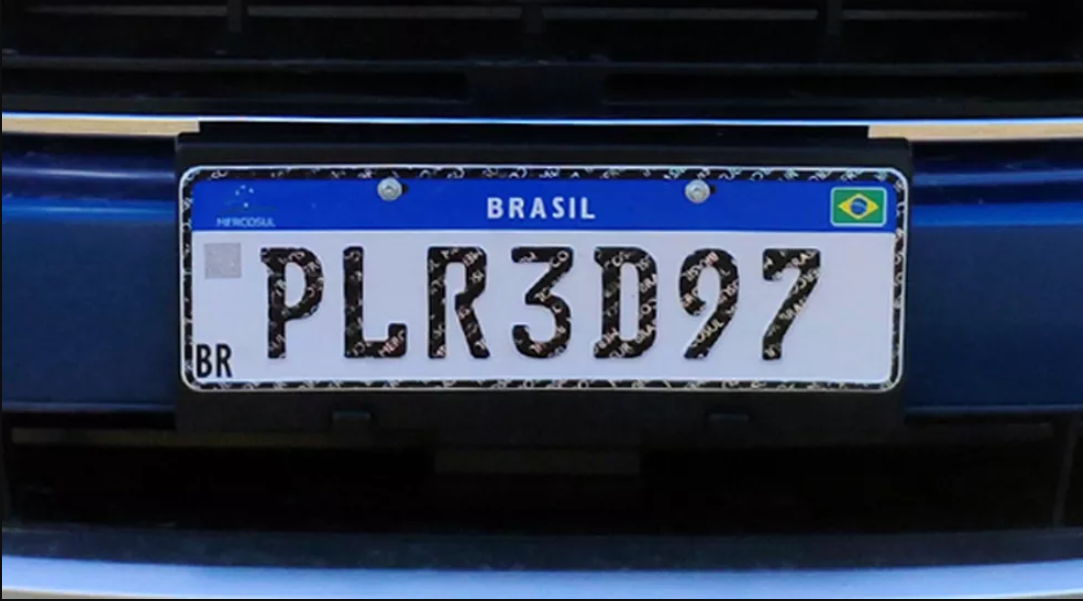

In [ ]:
imagem = cv2.imread('/content/placa_carro1.png')
cv2_imshow(imagem)

A biblioteca opencv importa as imagens com os canais BGR, como pode ser visto na [documentação](https://docs.opencv.org/3.4/d4/da8/group__imgcodecs.html)

> **Note**

> *In the case of color images, the decoded images will have the channels stored in B G R order.*

O tesseract entende os canais na ordem RGB, portanto devemos fazer uma conversão da imagem de BGR para GRAY(escala de cinza), com o uso da função `cv2.cvtColor()`

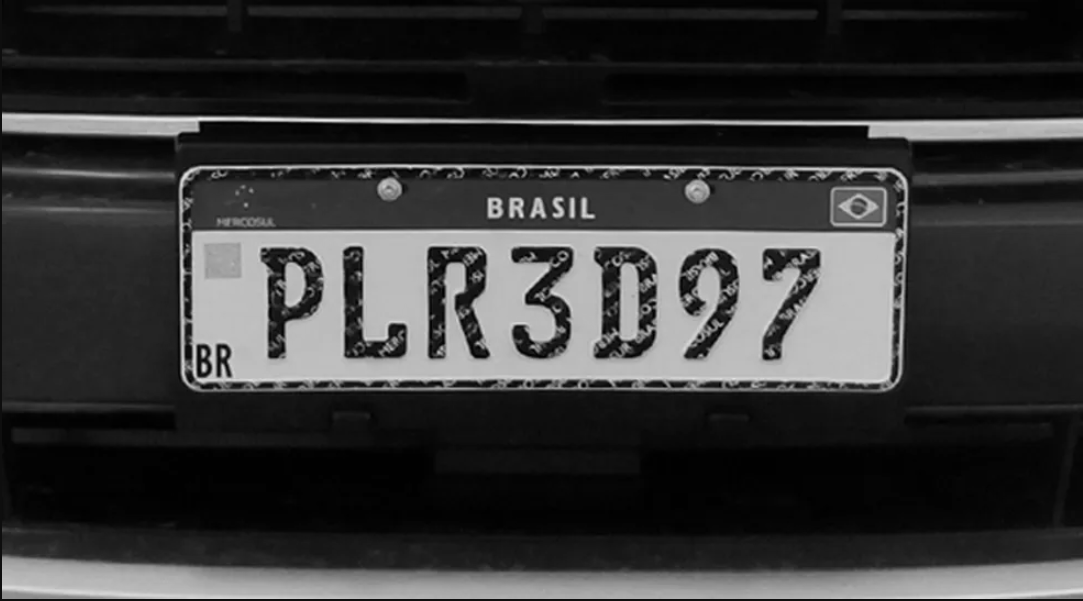

In [ ]:
imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)
cv2_imshow(imagem)

In [ ]:
config_tesseract = '--tessdata-dir tessdata'
texto = pytesseract.image_to_string(imagem, lang = 'por', config = config_tesseract)
print(texto)

# <font color='dark'>**Aula 2**</h1>

Para conseguir realizar melhor a detecção dos textos contidos na imagem, podemos aplicar pré-processamentos na imagem a fim de deixar os caracteres mais destacados do restante da imagem.

Um desses pré-processamentos é a limiarização, que consiste em transformar a imagem totalmente para preto e branco.

- [Documentação OpenCV: Limiarização](https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html)

### Limiarização simples

![](https://i.imgur.com/9diya8F.gif)

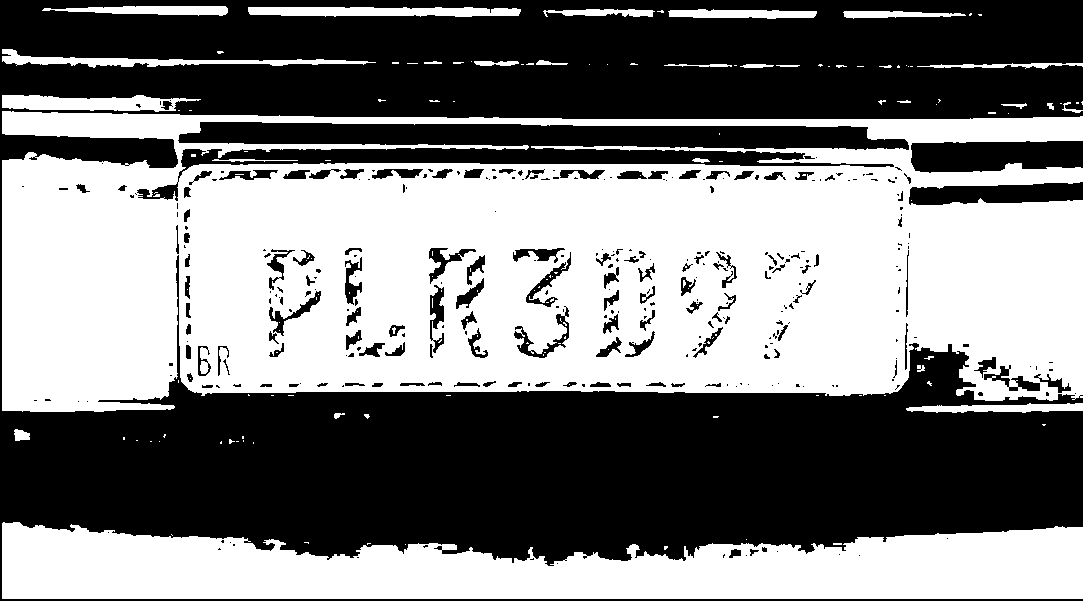

In [ ]:
limiar = 25
valor, lim_simples = cv2.threshold(imagem, limiar, 255, cv2.THRESH_BINARY)
cv2_imshow(lim_simples)

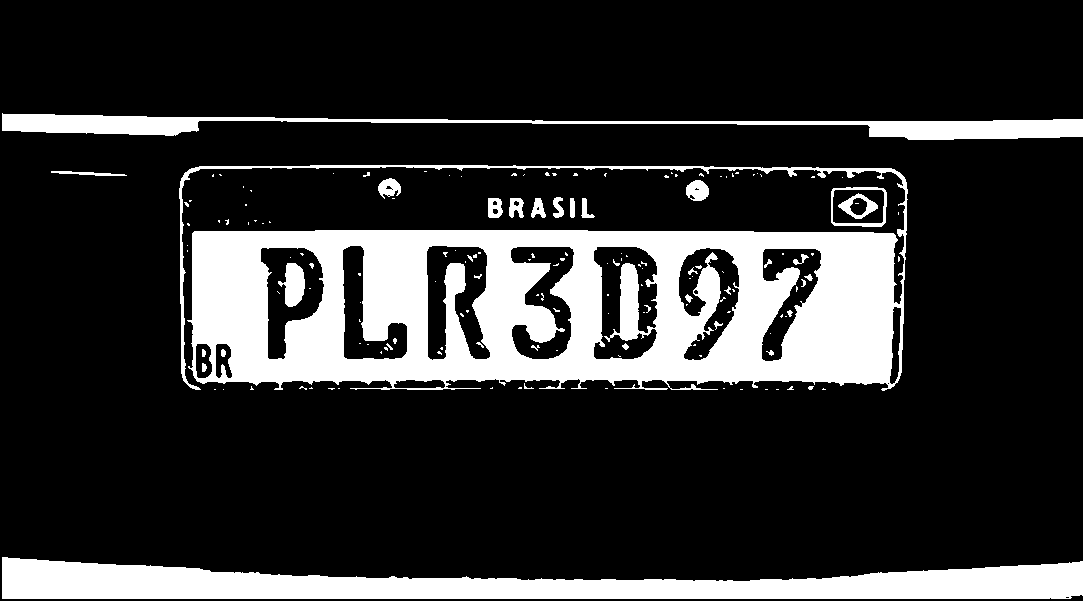

In [ ]:
limiar = 127
valor, lim_simples = cv2.threshold(imagem, limiar, 255, cv2.THRESH_BINARY)
cv2_imshow(lim_simples)

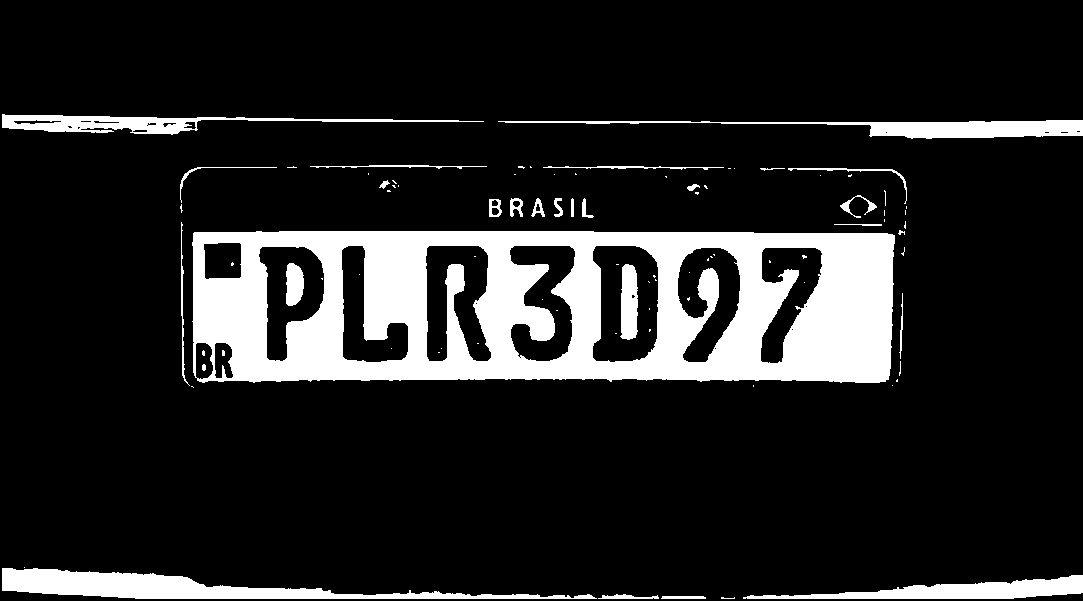

In [ ]:
limiar = 170
valor, lim_simples = cv2.threshold(imagem, limiar, 255, cv2.THRESH_BINARY)
cv2_imshow(lim_simples)

### Limiarização adaptativa

![](https://i.imgur.com/j6w6Rwu.gif)

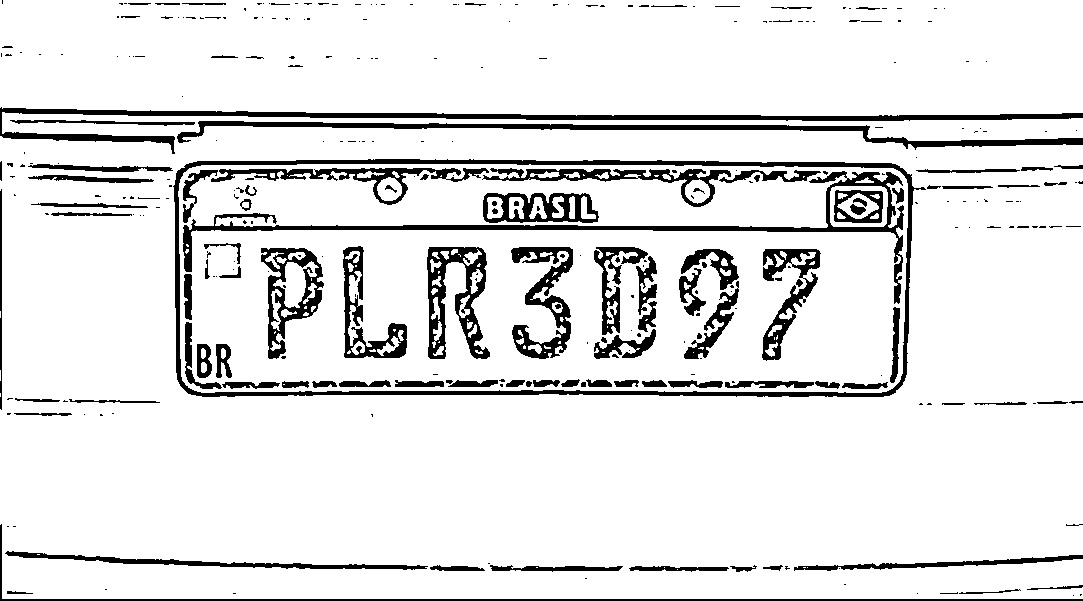

In [ ]:
lim_adapt = cv2.adaptiveThreshold(imagem, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 8)
cv2_imshow(lim_adapt)

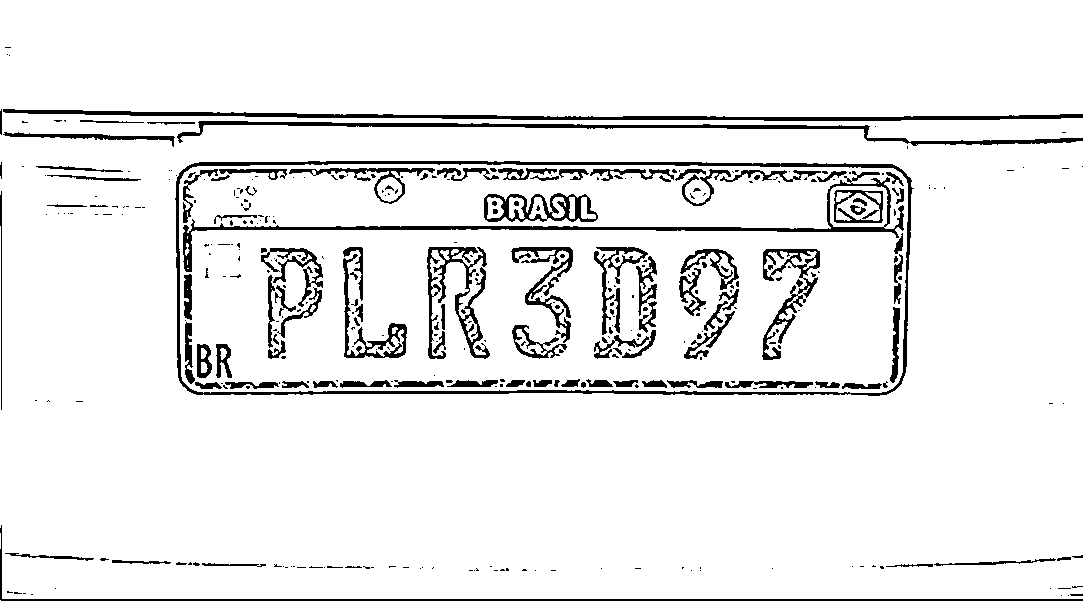

In [ ]:
lim_adapt = cv2.adaptiveThreshold(imagem, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 8)
cv2_imshow(lim_adapt)

### Limiarização de Otsu

Podemos ver a intensidade de cor de uma imagem através de histogramas. A documentação do opencv sugere algumas formas de criar histogramas a partir de imagens:

- [Documentação OpenCV: Histogramas](https://docs.opencv.org/4.x/d1/db7/tutorial_py_histogram_begins.html)

In [ ]:
imagem

array([[ 14,  14,   2, ...,   5,   5,   5],
       [ 14,  14,   2, ...,   5,   5,   5],
       [ 14,  14,   3, ...,   5,   5,   5],
       ...,
       [ 14,  14, 144, ..., 122, 121, 120],
       [ 14,  14,  14, ...,  14,  14,  14],
       [ 14,  14,  14, ...,  14,  14,  14]], dtype=uint8)

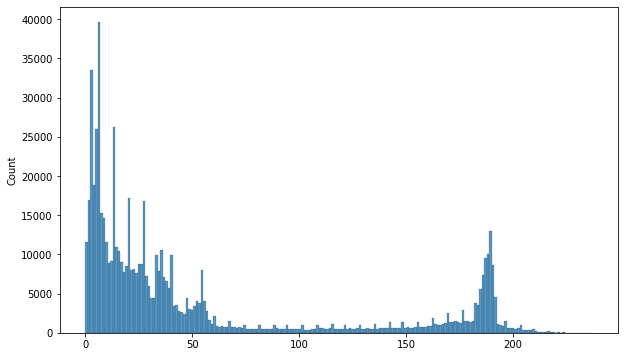

In [ ]:
import seaborn as sns
ax = sns.histplot(imagem.flatten())
ax.figure.set_size_inches(10,6)

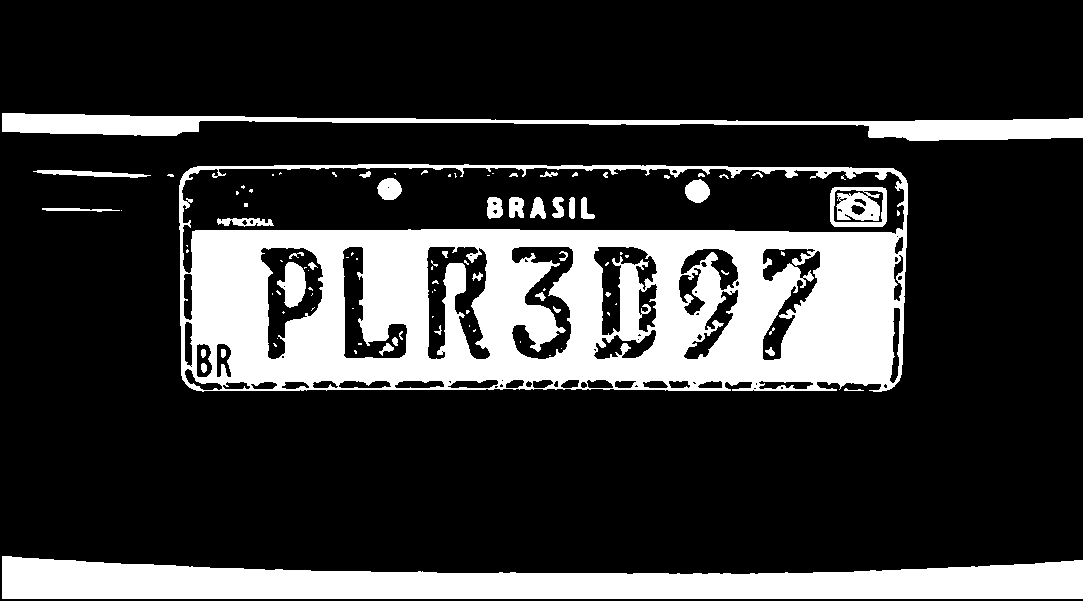

Limiar: 96.0


In [ ]:
valor, lim_otsu = cv2.threshold(imagem, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
cv2_imshow(lim_otsu)
print(f'Limiar: {valor}')

In [ ]:
config_tesseract = '--tessdata-dir tessdata'
texto = pytesseract.image_to_string(lim_otsu, lang = 'por', config = config_tesseract)
print(texto)